# Treinamento com MNIST (Banco de Imagens)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Puxando o arquivo da pasta src que criamos
import sys
sys.path.append('../src')
from model import CNN

# Verificando se tem GPU 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando na: {device}")

Rodando na: cpu


In [2]:
# Resize entra para garantir que qualquer dataset fique 28x28
transform = transforms.Compose([
    transforms.Resize((28, 28)), 
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalização básica
])

# Baixando o MNIST (vai salvar automaticamente em data/)
trainset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.43MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 265kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


In [3]:
# Aqui passamos num_canais=1 porque o MNIST é preto e branco (tons de cinza)
modelo = CNN(num_canais=1, num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
# Adam escolhido pois costuma convergir mais rápido que o SGD padrão e na atividade passada foi melhor
optimizer = optim.Adam(modelo.parameters(), lr=0.001)

In [4]:
epocas = 5 # 5 épocas 
historico_loss = []

modelo.train() # Avisa o pytorch que estamos treinando (importante por causa do dropout)

for epoch in range(epocas):
    loss_acumulada = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zera os gradientes da iteração anterior
        optimizer.zero_grad()

        # Forward (passa pra frente)
        outputs = modelo(inputs)
        loss = criterion(outputs, labels)
        
        # Backward (passa pra trás atualizando os pesos)
        loss.backward()
        optimizer.step()

        loss_acumulada += loss.item()
    
    loss_media = loss_acumulada / len(trainloader)
    historico_loss.append(loss_media)
    print(f"Época {epoch+1}/{epocas} - Loss: {loss_media:.4f}")

Época 1/5 - Loss: 0.2277
Época 2/5 - Loss: 0.0969
Época 3/5 - Loss: 0.0755
Época 4/5 - Loss: 0.0647
Época 5/5 - Loss: 0.0571


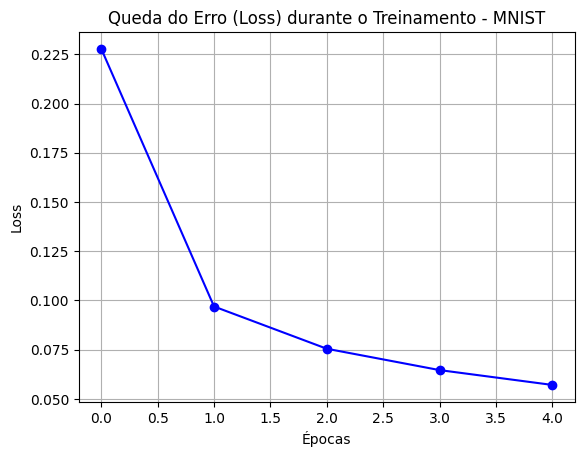

In [5]:
plt.plot(historico_loss, marker='o', color='b')
plt.title('Queda do Erro (Loss) durante o Treinamento - MNIST')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Treinamento com CIFAR

In [6]:
# cifar tem 3 canais, entao a normalizacao precisa de 3 valores (um pro R, G e B)
transform_cifar = transforms.Compose([
    transforms.Resize((28, 28)), # forçando o 28x28 pra nossa rede nao quebrar
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

# baixando o dataset de treino e teste
trainset_cifar = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform_cifar)
trainloader_cifar = torch.utils.data.DataLoader(trainset_cifar, batch_size=64, shuffle=True)

testset_cifar = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform_cifar)
testloader_cifar = torch.utils.data.DataLoader(testset_cifar, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [05:14<00:00, 542kB/s] 


In [7]:
# a unica diferenca aqui eh o num_canais=3
modelo_cifar = CNN(num_canais=3, num_classes=10).to(device)

optimizer_cifar = optim.Adam(modelo_cifar.parameters(), lr=0.001)

epocas_cifar = 5 
historico_loss_cifar = []

modelo_cifar.train() 

print("Começando o treino no CIFAR10...")
for epoch in range(epocas_cifar):
    loss_acumulada = 0.0
    for inputs, labels in trainloader_cifar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_cifar.zero_grad()

        outputs = modelo_cifar(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer_cifar.step()

        loss_acumulada += loss.item()
    
    loss_media = loss_acumulada / len(trainloader_cifar)
    historico_loss_cifar.append(loss_media)
    print(f"Época {epoch+1}/{epocas_cifar} - Loss: {loss_media:.4f}")

Começando o treino no CIFAR10...
Época 1/5 - Loss: 1.5637
Época 2/5 - Loss: 1.3174
Época 3/5 - Loss: 1.2206
Época 4/5 - Loss: 1.1521
Época 5/5 - Loss: 1.1051


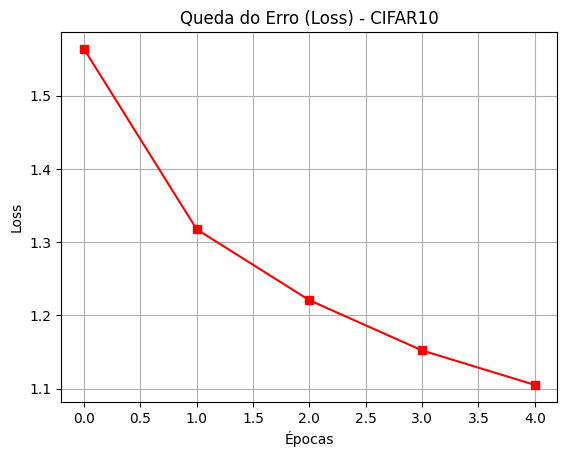

In [8]:
# mais um grafico pro documento
plt.plot(historico_loss_cifar, marker='s', color='r')
plt.title('Queda do Erro (Loss) - CIFAR10')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [9]:
# funcao simples pra testar o modelo e devolver a % de acerto
def calcula_acuracia(modelo, testloader):
    modelo.eval() # avisa a rede pra desligar o dropout
    acertos = 0
    total = 0
    
    # corta o calculo de gradiente pra poupar memoria
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = modelo(inputs)
            # pega a classe com a maior pontuacao (o q a rede acha q eh a imagem)
            _, previsao = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            acertos += (previsao == labels).sum().item()
            
    acuracia = 100 * acertos / total
    return acuracia

In [10]:
print("Calculando acertos, aguarde...")

# testando nossa cnn no mnist
acc_mnist = calcula_acuracia(modelo, testloader)
print(f"Acurácia da minha CNN no MNIST: {acc_mnist:.2f}%")

# testando a mesma arquitetura no cifar10
acc_cifar = calcula_acuracia(modelo_cifar, testloader_cifar)
print(f"Acurácia da minha CNN no CIFAR10: {acc_cifar:.2f}%")

Calculando acertos, aguarde...
Acurácia da minha CNN no MNIST: 99.06%
Acurácia da minha CNN no CIFAR10: 66.34%
